# Laboratorio 12 - APIs en Python
**Nombre:** Emilio Illanes  
**Fecha:** 10-06-2026


## Ejercicio 1

In [10]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import time
import json



In [11]:
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": -33.45,
    "longitude": -70.65,
    "current_weather": True
}

response = requests.get(url, params=params, timeout=10)
response.raise_for_status()

data = response.json()

print("Claves principales:", list(data.keys()))

print("\nJSON completo:")
print(json.dumps(data, indent=2))

Claves principales: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'current_weather_units', 'current_weather']

JSON completo:
{
  "latitude": -33.427067,
  "longitude": -70.64276,
  "generationtime_ms": 0.09930133819580078,
  "utc_offset_seconds": 0,
  "timezone": "GMT",
  "timezone_abbreviation": "GMT",
  "elevation": 554.0,
  "current_weather_units": {
    "time": "iso8601",
    "interval": "seconds",
    "temperature": "\u00b0C",
    "windspeed": "km/h",
    "winddirection": "\u00b0",
    "is_day": "",
    "weathercode": "wmo code"
  },
  "current_weather": {
    "time": "2026-06-10T16:45",
    "interval": 900,
    "temperature": 10.0,
    "windspeed": 2.2,
    "winddirection": 9,
    "is_day": 1,
    "weathercode": 51
  }
}


### reflexion 1
- si se usa un timeout tan pequeño, la API no podra alcanzar a responder antes de que se acabe el tiempo de espera. En ese caso se produce una excepción de tipo timeout

- `response.text` entrega texto plano; `response.json()` convierte el JSON a estructuras Python.
- Los parámetros aparecen codificados en la URL generada automáticamente por `params`.


## Ejercicio 2

In [12]:
def get_seguro(url, params=None, timeout=10):
    try:
        r = requests.get(url, params=params, timeout=timeout)
        r.raise_for_status()
        return r.json()

    except requests.exceptions.Timeout:
        print(f"[ERROR] Timeout: la API no respondio en {timeout}s")

    except requests.exceptions.HTTPError as e:
        codigo = e.response.status_code
        print(f"[ERROR] HTTP {codigo}: {e.response.reason}")

        if codigo == 404:
            print("Endpoint no encontrado. Revisa la URL.")
        elif codigo == 429:
            print("Limite de peticiones excedido. Usar time.sleep().")
        elif codigo == 401:
            print("No autorizado. Verificar API key.")

    except requests.exceptions.ConnectionError:
        print("[ERROR] Sin conexion o host invalido")

    except requests.exceptions.RequestException as e:
        print(f"[ERROR] Error inesperado: {e}")

    return None

r1 = get_seguro(
    "https://api.open-meteo.com/v1/forecast",
    params={"latitude": -33.45, "longitude": -70.65, "current_weather": True}
)

print("Caso 1:", r1["current_weather"] if r1 else None)

r2 = get_seguro("https://api.open-meteo.com/v1/ruta_invalida")
print("Caso 2:", r2)

r3 = get_seguro("https://api.open-meteo.com/v1/forecast", timeout=0.00001)
print("Caso 3:", r3)


Caso 1: {'time': '2026-06-10T16:45', 'interval': 900, 'temperature': 10.0, 'windspeed': 2.2, 'winddirection': 9, 'is_day': 1, 'weathercode': 51}
[ERROR] HTTP 404: Not Found
Endpoint no encontrado. Revisa la URL.
Caso 2: None
[ERROR] Timeout: la API no respondio en 1e-05s
Caso 3: None


### reflexion 2
-El timeout evitara que el programa se quede esperando de manera indefinida.

-`raise_for_status()` transforma los códigos HTTP de error en excepciones.

-Timeout cuando el servidor tarda demasiado; HTTPError cuando responde con
error; ConnectionError cuando no se puede establecer conexión


## Ejercicio 3

In [13]:
def consumir_paginado(url, limite=20, max_paginas=20):
    todos = []
    pagina = 1

    while pagina <= max_paginas:
        resultado = get_seguro(url, params={"_page": pagina, "_limit": limite})

        if resultado is None:
            break

        if not resultado:
            print(f"Fin de datos en pagina {pagina}")
            break

        todos.extend(resultado)

        print(f"Pagina {pagina:2d}: {len(resultado):3d} registros | Total: {len(todos)}")

        pagina += 1
        time.sleep(0.1)

    return todos

posts = consumir_paginado(
    "https://jsonplaceholder.typicode.com/posts",
    limite=20
)

df_posts = pd.DataFrame(posts)

print(df_posts.shape)
print(df_posts.head())
print(df_posts.dtypes)

resumen = df_posts.groupby("userId").agg(
    total_posts=("id", "count"),
    largo_promedio=("body", lambda x: x.str.len().mean().round(1))
).reset_index()

print(resumen)

df_posts.to_csv("posts.csv", index=False)
resumen.to_csv("resumen_usuarios.csv", index=False)


Pagina  1:  20 registros | Total: 20
Pagina  2:  20 registros | Total: 40
Pagina  3:  20 registros | Total: 60
Pagina  4:  20 registros | Total: 80
Pagina  5:  20 registros | Total: 100
Fin de datos en pagina 6
(100, 4)
   userId  id                                              title  \
0       1   1  sunt aut facere repellat provident occaecati e...   
1       1   2                                       qui est esse   
2       1   3  ea molestias quasi exercitationem repellat qui...   
3       1   4                               eum et est occaecati   
4       1   5                                 nesciunt quas odio   

                                                body  
0  quia et suscipit\nsuscipit recusandae consequu...  
1  est rerum tempore vitae\nsequi sint nihil repr...  
2  et iusto sed quo iure\nvoluptatem occaecati om...  
3  ullam et saepe reiciendis voluptatem adipisci\...  
4  repudiandae veniam quaerat sunt sed\nalias aut...  
userId     int64
id         int64
title  

### Reflexión 3
-Si la primera página viene vacía, el proceso termina de forma inmediata

-`max_paginas` evita los bucles infinitos

-`DataFrame(lista_de_dicts)` simplifica enormemente la construcción de tablas

## Ejercicio 4

Extrayendo Santiago...
Extrayendo Concepcion...
Extrayendo Antofagasta...
        ciudad       fecha  temp_max  temp_min  temp_prom
0  Antofagasta  2026-06-10      17.8      13.8       15.6
1  Antofagasta  2026-06-11      18.6      14.6       16.1
2  Antofagasta  2026-06-12      18.7      14.1       16.3
3   Concepcion  2026-06-10      13.4       7.4       10.8
4   Concepcion  2026-06-11      11.8       4.7        8.4
5   Concepcion  2026-06-12      11.6       8.5       10.4
6     Santiago  2026-06-10      11.5       7.1        8.9
7     Santiago  2026-06-11      16.0       3.4        9.6
8     Santiago  2026-06-12      19.1      10.6       13.9


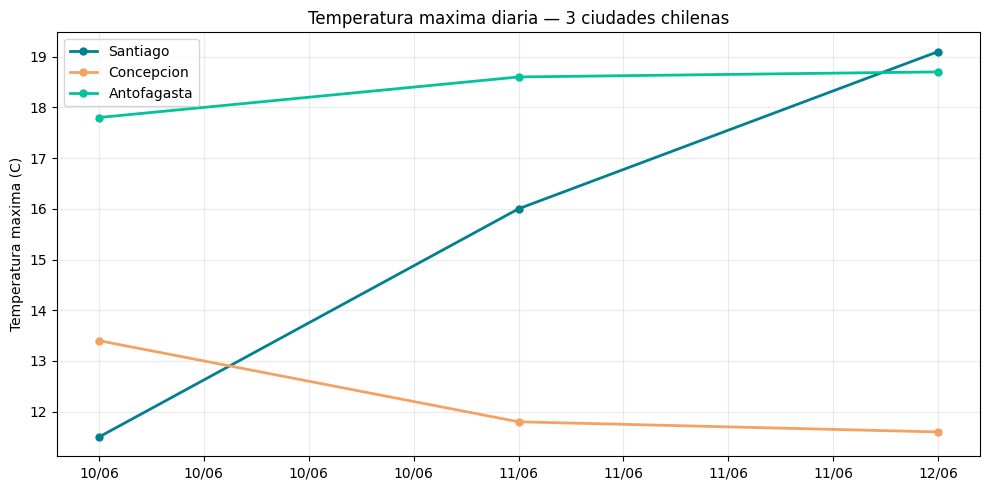

In [14]:
def obtener_clima(lat, lon, dias=3):
    data = get_seguro(
        "https://api.open-meteo.com/v1/forecast",
        params={
            "latitude": lat,
            "longitude": lon,
            "hourly": "temperature_2m,precipitation_probability",
            "forecast_days": dias,
            "timezone": "America/Santiago"
        }
    )

    if data is None:
        return None

    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    return df

CIUDADES = {
    "Santiago": (-33.45, -70.65),
    "Concepcion": (-36.82, -73.04),
    "Antofagasta": (-23.65, -70.40)
}

datos = {}

for ciudad, (lat, lon) in CIUDADES.items():
    print(f"Extrayendo {ciudad}...")
    datos[ciudad] = obtener_clima(lat, lon, dias=3)
    time.sleep(0.3)

frames = []

for ciudad, df in datos.items():
    if df is not None:
        df["ciudad"] = ciudad
        df["fecha"] = df["time"].dt.date
        frames.append(df)

df_all = pd.concat(frames, ignore_index=True)

resumen_diario = df_all.groupby(["ciudad", "fecha"]).agg(
    temp_max=("temperature_2m", "max"),
    temp_min=("temperature_2m", "min"),
    temp_prom=("temperature_2m", "mean")
).round(1).reset_index()

print(resumen_diario)

resumen_diario.to_csv("resumen_clima.csv", index=False)

fig, ax = plt.subplots(figsize=(10,5))

colores = ["#028090", "#F4A261", "#02C39A"]

for ciudad, color in zip(CIUDADES.keys(), colores):
    df_c = resumen_diario[resumen_diario["ciudad"] == ciudad]
    fechas = pd.to_datetime(df_c["fecha"])

    ax.plot(
        fechas,
        df_c["temp_max"],
        marker="o",
        label=ciudad,
        color=color,
        linewidth=2,
        markersize=5
    )

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax.set_title("Temperatura maxima diaria — 3 ciudades chilenas")
ax.set_ylabel("Temperatura maxima (C)")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("comparacion_temp.png", dpi=150, bbox_inches="tight")
plt.show()


### Reflexión 4
-Porque ayuda a ordenar mejor los elementos del gráfico. Así se evita que los títulos, etiquetas o la leyenda queden cortados cuando se guarda la imagen.

-Solo agregaría una nueva ciudad al diccionario CIUDADES con su latitud y longitud. El resto del código seguiría funcionando

-Primero se extrajeron los datos climáticos desde la API de Open-Meteo. Después se transformaron los datos creando DataFrames y calculando estadísticas como temperatura máxima, mínima y promedio y para finalizar los resultados se guardaron en un archivo CSV y se mostraron en un gráfico para comparar las ciudades.
